In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to sys.path to allow importing from src
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

try:
    from src.strategies import ID_TO_NAME
except ImportError:
    # Fallback if import fails
    ID_TO_NAME = {0: 'Undercut', 1: 'Match', 2: 'Above', 3: 'UnderReset', 4: 'MatchReset'}

# Setup Plotting Style
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (15, 6)

In [2]:
def load_parquet(file_path):
    path = Path(file_path)
    if not path.exists():
        print(f"File not found: {path}")
        return None
    return pd.read_parquet(path)

def load_all_parquets_in_dir(dir_path):
    path = Path(dir_path)
    if not path.exists():
        print(f"Directory not found: {path}")
        return []
    files = sorted(list(path.glob("*.parquet")))
    print(f"Found {len(files)} parquet files in {dir_path}")
    return [pd.read_parquet(f) for f in files]

## 1. Single Run History (Prices, Delta, Std Dev)

In [3]:
# === SET PATHS HERE ===

# Example Path to a Experiment Config (containing N_x folders)
# root = project_root / "data" / "results" / "scan_3strats_mu0.01_k30"
# specific_config_dir = root / "N_7"
# specific_parquet = specific_config_dir / "run_0.parquet"

# # Please uncomment and set your actual paths:
# plot_single_run_history(specific_parquet)
# plot_single_run_action_shares(specific_parquet)

# plot_aggregate_price_history(specific_config_dir)
# plot_aggregate_action_shares(specific_config_dir)

In [4]:
# --- Quick & Simple Price History Plot ---
# Modify 'max_steps' below to change the length of the history shown
root = project_root / "data" / "results" / "scan_3strats_mu0.01_k30"
specific_config_dir = root / "N_7"
specific_parquet = specific_config_dir / "run_25.parquet"

target_path = specific_parquet

# 1. Read Data
df_simple = pd.read_parquet(target_path)

In [5]:
df_simple.head()

,run_id,t_global,episode,step_in_k,price_min,price_mean,delta,converged,is_cycle,a_0,...,pi_3,a_4,p_4,pi_4,a_5,p_5,pi_5,a_6,p_6,pi_6
0,25,0,603327,0,0.874223,0.874223,-1.443576e-01,True,False,2,...,-0.017968,2,0.874223,-1.796811e-02,2,0.874223,-1.796811e-02,2,0.874223,-1.796811e-02
1,25,1,603327,1,0.874223,0.992032,-1.443566e-01,True,False,2,...,-0.125776,2,1.011667,1.252700e-08,2,1.011667,1.252700e-08,2,1.011667,1.252700e-08
2,25,2,603327,2,1.011667,1.011667,1.594232e-18,True,False,2,...,0.001667,2,1.011667,1.666768e-03,2,1.011667,1.666768e-03,2,1.011667,1.666768e-03
3,25,3,603327,3,1.011667,1.129477,9.299612e-07,True,False,2,...,0.011667,2,1.149112,1.600977e-07,2,1.149112,1.600977e-07,2,1.149112,1.600977e-07
4,25,4,603327,4,1.149112,1.149112,1.443576e-01,True,False,2,...,0.021302,2,1.149112,2.130164e-02,2,1.149112,2.130164e-02,2,1.149112,2.130164e-02


In [6]:
df_simple.columns

Index(['run_id', 't_global', 'episode', 'step_in_k', 'price_min', 'price_mean',
       'delta', 'converged', 'is_cycle', 'a_0', 'p_0', 'pi_0', 'a_1', 'p_1',
       'pi_1', 'a_2', 'p_2', 'pi_2', 'a_3', 'p_3', 'pi_3', 'a_4', 'p_4',
       'pi_4', 'a_5', 'p_5', 'pi_5', 'a_6', 'p_6', 'pi_6'],
      dtype='object')

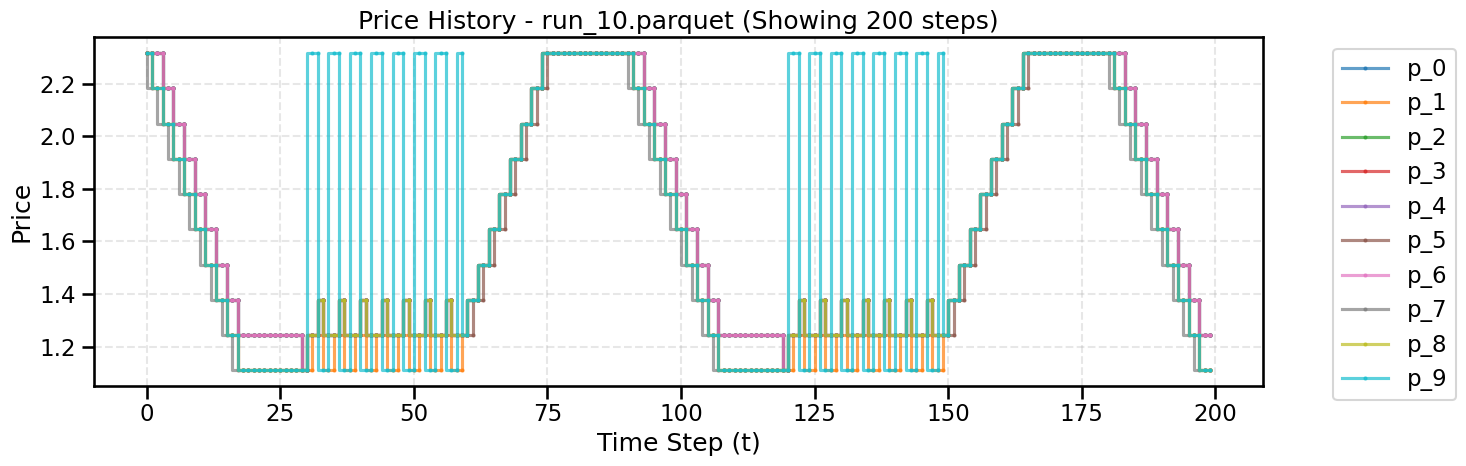

In [7]:
root = project_root / "data" / "results" / "scan_4strats_mu0.22_k30"
specific_config_dir = root / "N_10"
specific_parquet = specific_config_dir / "run_10.parquet"

target_path = specific_parquet

# 1. Read Data
df_simple = pd.read_parquet(target_path)

max_steps = 200   # Set to an integer (e.g., 50, 200) or None to see full history

# 2. Slice Data
if max_steps is not None:
    plot_data = df_simple.iloc[:max_steps]
else:
    plot_data = df_simple

# 3. Plot
plt.figure(figsize=(15, 5))

# Find all columns starting with 'p_' (e.g. p_0, p_1...)
p_cols = [c for c in plot_data.columns if c.startswith('p_')]

for col in p_cols:
    plt.step(plot_data['t_global'], plot_data[col], label=col, marker='.', markersize=4, alpha=0.7)
    
plt.title(f"Price History - {target_path.name} (Showing {len(plot_data)} steps)")
plt.xlabel("Time Step (t)")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


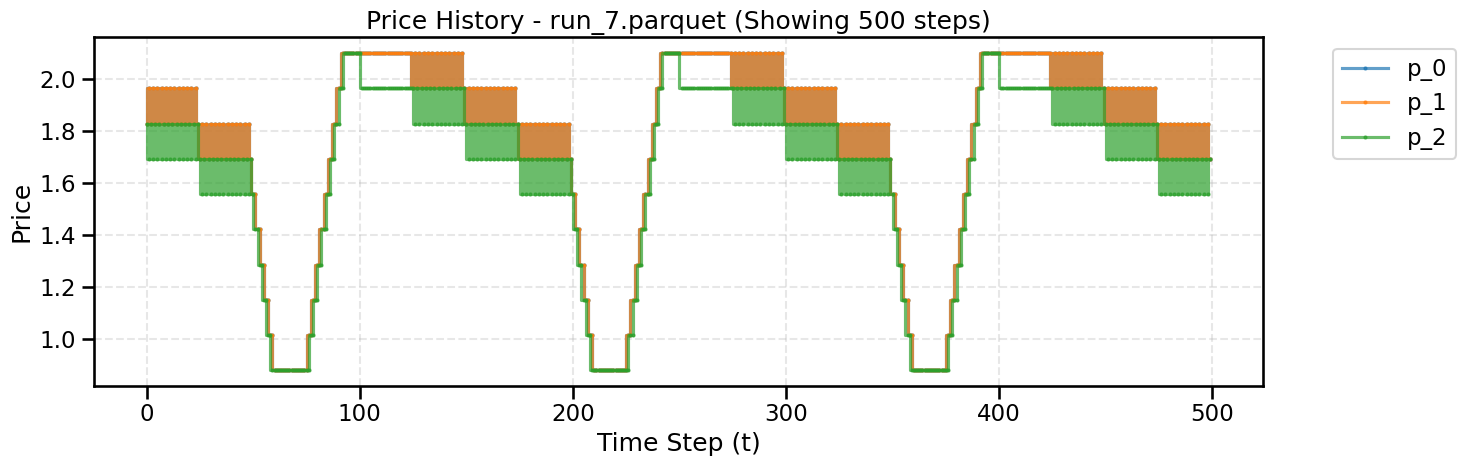

In [10]:
root = project_root / "data" / "results" / "scan_3strats_mu0.01_k25"
specific_config_dir = root / "N_3"
specific_parquet = specific_config_dir / "run_7.parquet"

target_path = specific_parquet

# 1. Read Data
df_simple = pd.read_parquet(target_path)

max_steps = 500   # Set to an integer (e.g., 50, 200) or None to see full history

# 2. Slice Data
if max_steps is not None:
    plot_data = df_simple.iloc[:max_steps]
else:
    plot_data = df_simple

# 3. Plot
plt.figure(figsize=(15, 5))

# Find all columns starting with 'p_' (e.g. p_0, p_1...)
p_cols = [c for c in plot_data.columns if c.startswith('p_')]

for col in p_cols:
    plt.step(plot_data['t_global'], plot_data[col], label=col, marker='.', markersize=4, alpha=0.7)
    
plt.title(f"Price History - {target_path.name} (Showing {len(plot_data)} steps)")
plt.xlabel("Time Step (t)")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


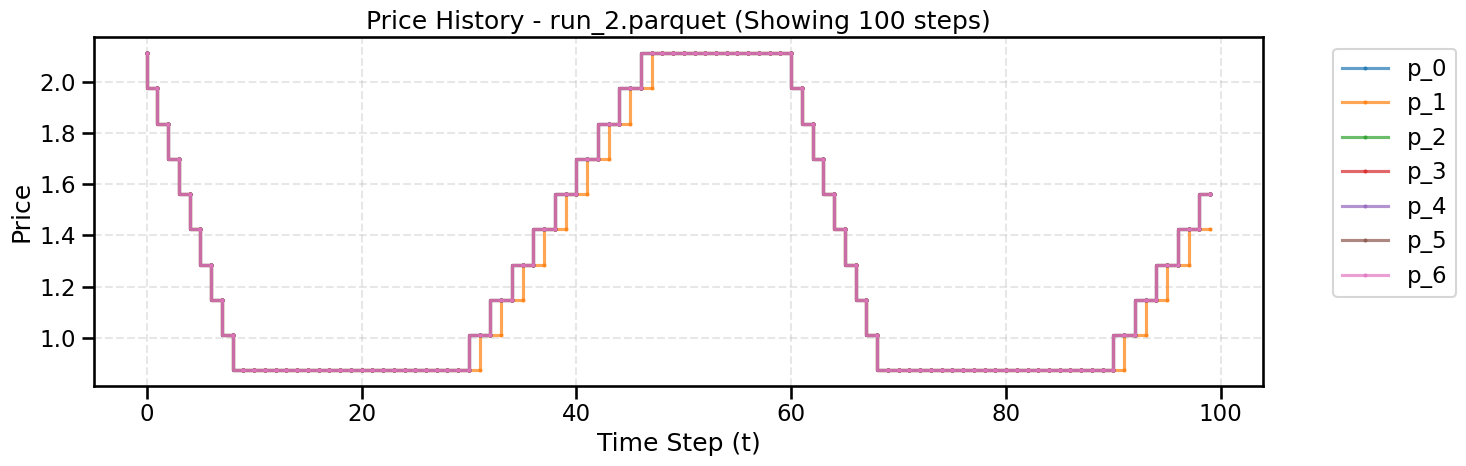

In [20]:
root = project_root / "data" / "results" / "scan_3strats_mu0.01_k30"
specific_config_dir = root / "N_7"
specific_parquet = specific_config_dir / "run_2.parquet"

target_path = specific_parquet

# 1. Read Data
df_simple = pd.read_parquet(target_path)

max_steps = 100   # Set to an integer (e.g., 50, 200) or None to see full history

# 2. Slice Data
if max_steps is not None:
    plot_data = df_simple.iloc[:max_steps]
else:
    plot_data = df_simple

# 3. Plot
plt.figure(figsize=(15, 5))

# Find all columns starting with 'p_' (e.g. p_0, p_1...)
p_cols = [c for c in plot_data.columns if c.startswith('p_')]

for col in p_cols:
    plt.step(plot_data['t_global'], plot_data[col], label=col, marker='.', markersize=4, alpha=0.7)
    
plt.title(f"Price History - {target_path.name} (Showing {len(plot_data)} steps)")
plt.xlabel("Time Step (t)")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


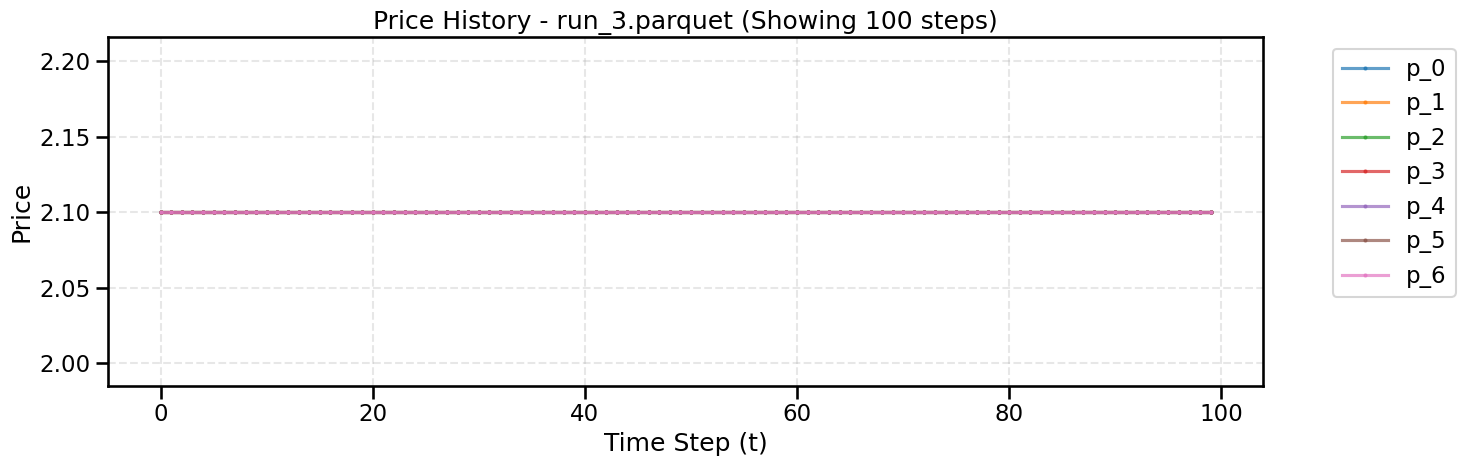

In [ ]:
root = project_root / "data" / "results" / "scan_3strats_mu0.1_k25"
specific_config_dir = root / "N_7"
specific_parquet = specific_config_dir / "run_3.parquet"

max_steps = 100   # Set to an integer (e.g., 50, 200) or None to see full history
target_path = specific_parquet


# 1. Read Data
df_simple = pd.read_parquet(target_path)

# 2. Slice Data
if max_steps is not None:
    plot_data = df_simple.iloc[:max_steps]
else:
    plot_data = df_simple

# 3. Plot
plt.figure(figsize=(15, 5))

# Find all columns starting with 'p_' (e.g. p_0, p_1...)
p_cols = [c for c in plot_data.columns if c.startswith('p_')]

for col in p_cols:
    plt.step(plot_data['t_global'], plot_data[col], label=col, marker='.', markersize=4, alpha=0.7)
    
plt.title(f"Price History - {target_path.name} (Showing {len(plot_data)} steps)")
plt.xlabel("Time Step (t)")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


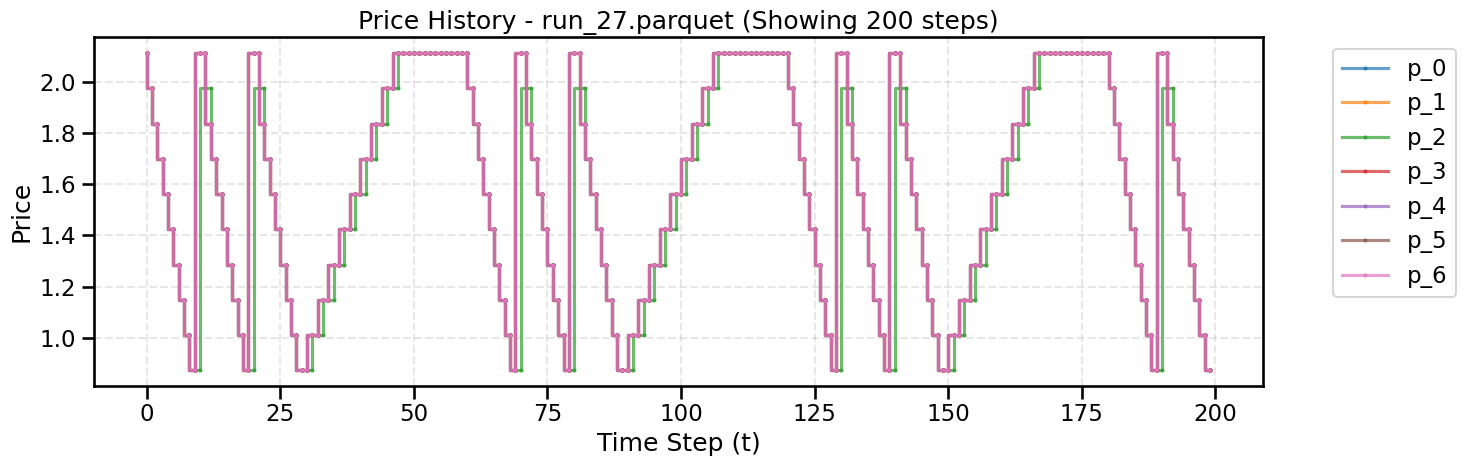

In [43]:
root = project_root / "data" / "results" / "scan_4strats_mu0.01_k30"
specific_config_dir = root / "N_7"
specific_parquet = specific_config_dir / "run_27.parquet"

max_steps = 200   # Set to an integer (e.g., 50, 200) or None to see full history
target_path = specific_parquet


# 1. Read Data
df_simple = pd.read_parquet(target_path)

# 2. Slice Data
if max_steps is not None:
    plot_data = df_simple.iloc[:max_steps]
else:
    plot_data = df_simple

# 3. Plot
plt.figure(figsize=(15, 5))

# Find all columns starting with 'p_' (e.g. p_0, p_1...)
p_cols = [c for c in plot_data.columns if c.startswith('p_')]

for col in p_cols:
    plt.step(plot_data['t_global'], plot_data[col], label=col, marker='.', markersize=4, alpha=0.7)
    
plt.title(f"Price History - {target_path.name} (Showing {len(plot_data)} steps)")
plt.xlabel("Time Step (t)")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


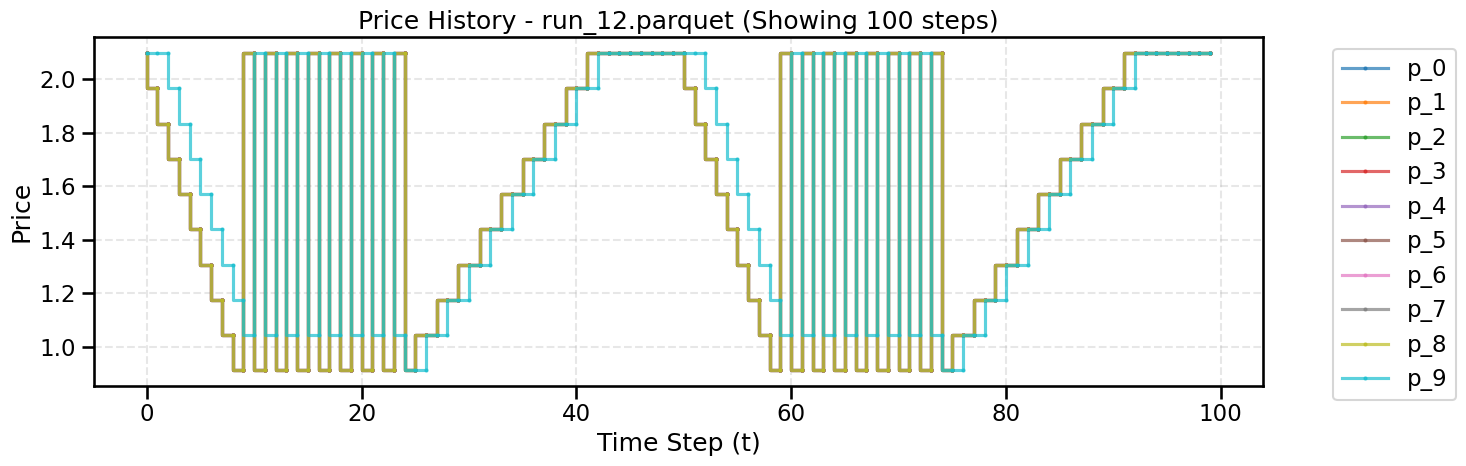

In [ ]:
root = project_root / "data" / "results" / "scan_4strats_mu0.04_k25"
specific_config_dir = root / "N_10"
specific_parquet = specific_config_dir / "run_12.parquet"

max_steps = 100   # Set to an integer (e.g., 50, 200) or None to see full history
target_path = specific_parquet


# 1. Read Data
df_simple = pd.read_parquet(target_path)

# 2. Slice Data
if max_steps is not None:
    plot_data = df_simple.iloc[:max_steps]
else:
    plot_data = df_simple

# 3. Plot
plt.figure(figsize=(15, 5))

# Find all columns starting with 'p_' (e.g. p_0, p_1...)
p_cols = [c for c in plot_data.columns if c.startswith('p_')]

for col in p_cols:
    plt.step(plot_data['t_global'], plot_data[col], label=col, marker='.', markersize=4, alpha=0.7)
    
plt.title(f"Price History - {target_path.name} (Showing {len(plot_data)} steps)")
plt.xlabel("Time Step (t)")
plt.ylabel("Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
